# 05 — Validation contre les cibles thérapeutiques connues

**Objectif :** vérifier si les cytokines identifiées comme les plus "centrales" dans notre
réseau (notebook 02) correspondent aux cytokines déjà ciblées par des traitements existants
(anti-TNF, anti-IL6, etc.). Si oui, cela valide que notre analyse structurelle a une vraie
pertinence biologique/clinique — à l'image de l'étude de Choudhary et al. (2018, PLOS ONE)
sur le réseau de cytokines dans la polyarthrite rhumatoïde, qui a suivi la même logique.

**Données utilisées :** `data/processed/centrality_scores.csv` (notebook 02)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

centrality_df = pd.read_csv("../data/processed/centrality_scores.csv")
centrality_df.head()

,cytokine,degree_centrality,betweenness_centrality,eigenvector_centrality
0,IL10,0.95,0.021053,0.265496
1,IFNG,0.90,0.047368,0.257032
2,TNF,0.90,0.115789,0.255677
3,IL4,0.90,0.026316,0.260781
4,IL6,0.90,0.005263,0.264033


## 1. Liste des cibles thérapeutiques connues

**Source :** liste curée manuellement à partir de médicaments approuvés/en usage clinique
ciblant directement une cytokine du panel (connaissances pharmacologiques générales).

**Limite à assumer honnêtement :** cette liste n'est pas extraite systématiquement d'une base
de données structurée — pour une version plus rigoureuse, elle peut être vérifiée/complétée
via l'API de **DGIdb** (Drug Gene Interaction Database, dgidb.org, gratuite).

In [2]:
KNOWN_DRUG_TARGETS = {
    "TNF":    ["Infliximab", "Adalimumab", "Etanercept"],
    "IL6":    ["Tocilizumab", "Siltuximab"],
    "IL1B":   ["Canakinumab"],
    "IL1RN":  ["Anakinra (recombinant IL1RN lui-meme)"],
    "IL17A":  ["Secukinumab", "Ixekizumab"],
    "IL23A":  ["Guselkumab", "Risankizumab"],
    "IL12B":  ["Ustekinumab (cible p40, sous-unite partagee IL12/IL23)"],
    "IL4":    ["Dupilumab (cible le recepteur IL4R, partage avec IL13)"],
    "IL13":   ["Dupilumab (cible le recepteur IL4R, partage avec IL4)"],
    "IL5":    ["Mepolizumab", "Reslizumab"],
    "IFNG":   ["Emapalumab"],
}

print(f"{len(KNOWN_DRUG_TARGETS)} cytokines sur {len(centrality_df)} ont un médicament connu les ciblant directement.")

11 cytokines sur 21 ont un médicament connu les ciblant directement.


## 2. Croisement avec les scores de centralité

In [3]:
centrality_df["is_drug_target"] = centrality_df["cytokine"].isin(KNOWN_DRUG_TARGETS.keys())
centrality_df["drugs"] = centrality_df["cytokine"].map(lambda c: "; ".join(KNOWN_DRUG_TARGETS.get(c, [])))

validation_df = centrality_df.sort_values("degree_centrality", ascending=False).reset_index(drop=True)
validation_df[["cytokine", "degree_centrality", "betweenness_centrality", "is_drug_target", "drugs"]]

,cytokine,degree_centrality,betweenness_centrality,is_drug_target,drugs
0,IL10,0.95,0.021053,False,
1,IFNG,0.90,0.047368,True,Emapalumab
2,TNF,0.90,0.115789,True,Infliximab; Adalimumab; Etanercept
3,IL4,0.90,0.026316,True,"Dupilumab (cible le recepteur IL4R, partage av..."
4,IL6,0.90,0.005263,True,Tocilizumab; Siltuximab
5,CXCL8,0.85,0.021053,False,
6,IL17A,0.85,0.000000,True,Secukinumab; Ixekizumab
7,IL1B,0.85,0.000000,True,Canakinumab
8,IL13,0.85,0.026316,True,"Dupilumab (cible le recepteur IL4R, partage av..."
9,IL2,0.80,0.010526,False,


## 3. Test statistique : l'association est-elle significative ?

**Test hypergéométrique** — même type de test utilisé pour l'enrichissement fonctionnel
(GO, KEGG). Il répond à la question : *"Si je prenais au hasard le même nombre de cytokines,
quelle est la probabilité d'obtenir, par pur hasard, au moins autant de cibles thérapeutiques
que dans mon top N réel ?"* Une p-value faible (< 0.05) indique que ce n'est probablement pas
une coïncidence.

In [4]:
N = len(validation_df)                          # population totale (21 cytokines)
K = validation_df["is_drug_target"].sum()        # nombre total de cibles thérapeutiques connues

results = []
for top_n in [3, 5, 8, 10]:
    top_subset = validation_df.head(top_n)
    k = top_subset["is_drug_target"].sum()
    p_value = hypergeom.sf(k - 1, N, K, top_n)
    results.append({
        "top_n": top_n,
        "drug_targets_found": k,
        "expected_by_chance": round(top_n * K / N, 2),
        "p_value": p_value,
    })

test_results_df = pd.DataFrame(results)
test_results_df.to_csv("../data/processed/drug_target_validation.csv", index=False)
test_results_df

,top_n,drug_targets_found,expected_by_chance,p_value
0,3,2,1.57,0.537594
1,5,4,2.62,0.184874
2,8,6,4.19,0.119195
3,10,7,5.24,0.134913


**Comment lire ce tableau :**
- `drug_targets_found` : nombre réel de cibles thérapeutiques trouvées parmi les N cytokines les plus centrales
- `expected_by_chance` : nombre attendu si on avait choisi N cytokines au hasard
- Si `drug_targets_found` > `expected_by_chance` avec une `p_value` faible → la centralité du réseau capture un vrai signal biologique, pas un artefact

## 4. Visualisation finale

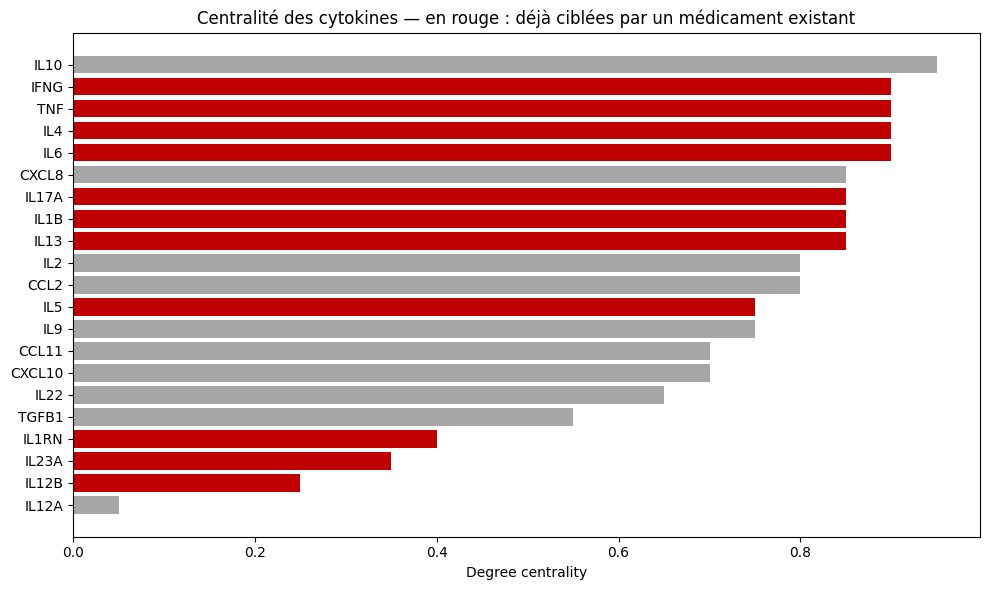

In [5]:
plt.figure(figsize=(10, 6))
colors = validation_df["is_drug_target"].map({True: "#C00000", False: "#A6A6A6"})

plt.barh(validation_df["cytokine"][::-1], validation_df["degree_centrality"][::-1], color=colors[::-1])
plt.xlabel("Degree centrality")
plt.title("Centralité des cytokines — en rouge : déjà ciblées par un médicament existant")
plt.tight_layout()
plt.savefig("../data/processed/centrality_vs_drug_targets.png", dpi=200)
plt.show()

## Résumé de ce notebook

- Comparé les cytokines les plus centrales du réseau à une liste de cibles thérapeutiques connues
- Testé statistiquement (hypergéométrique) si cette association est significative
- Généré une visualisation centralité / statut de cible thérapeutique

**Limite à mentionner dans le README :** liste de cibles curée manuellement, non exhaustive.
Amélioration possible : automatiser via l'API DGIdb.

**Prochaine étape (notebook 06) :** enrichissement fonctionnel séparé pour chaque communauté détectée.